# SPHEREx Anomaly Detection — Inference Pipeline (`v0.2`, `.npy` input)

---

## Overview

This notebook implements an inference pipeline for detecting anomalies in **SPHEREx satellite images**. Given a set of raw 6-band `.npy` files (shape: `6 × 2040 × 2040`), the pipeline preprocesses each image on-the-fly and runs it through a pretrained **Vision Transformer (ViT)** binary classifier to produce an anomaly probability score per image.

All functions are encapsulated in `spherex_anomaly_vit.py` — no model or preprocessing code is defined in this notebook.

---

## Pipeline
```
raw .npy (6, 2040, 2040)
    ↓  8×8 block mean → downsize (6, 255, 255)
    ↓  NaN → quality map (6, 255, 255)  [0, 1]
    ↓  per-band Median MAD Scaling → NaN→0 → clip [-5, 5]
    ↓  3 tiles concat → 4-channel image (4, 255, 765)
    ↓  ViT Binary Classifier → anomaly probability [0, 1]
```

| Input Channel | Description |
|---|---|
| bandA | bands 1, 2, 3 concatenated horizontally |
| bandB | bands 4, 5, 6 concatenated horizontally |
| qualA | quality map of bands 1, 2, 3 |
| qualB | quality map of bands 4, 5, 6 |

---

## Pretrained Model

| Item | Value |
|---|---|
| Architecture | Vision Transformer Binary Classifier |
| Input resolution | 255 × 765 (patch size 15×15, 867 tokens) |
| Training data | 2,885 (anomaly) + 4,796 (normal) = 7,681 samples |
| Best checkpoint | `best-epoch=011-val_AUROC=0.9022.ckpt` |
| Test AUROC | **0.9022** |

### Best Thresholds (on Test Set)

| Strategy | Threshold | Note |
|---|---|---|
| Maximize F1 | 0.9290 | F1 = 0.8398 |
| Youden's J | 0.8845 | Maximizes TPR − FPR |
| Precision ≥ 0.9 | 0.9550 | Recall = 0.7737 |

---

## Performance Notes

- **Main bottleneck**: on-the-fly preprocessing (downsampling + robust scaling + 4-channel construction), not the model forward pass.
- **`num_workers`** is the most critical tuning parameter. On a 16-thread / 8 physical core machine, `num_workers=8` reduced inference time from **~40 min → ~17 min** for 3,715 files.
- **GPU inference** showed marginal or no speedup over CPU, since the preprocessing bottleneck is CPU-bound. Switching to GPU only adds data transfer overhead (`CPU → GPU`) without meaningful reduction in total wall time.

---

## Required Files
```
├── spherex_anomaly_vit.py                       # preprocessing + model + inference + visualization
├── best-epoch=011-val_AUROC=0.9022.ckpt        # pretrained weights
└── test-images/                                 # .npy files to run inference on
```

## Steps

1. **Set paths** — pretrained model path, test image directory
2. **Load model** — `load_model(ckpt_path)`
3. **Build DataLoader** — `file_list` → `build_dataloader(file_list, num_workers=8)`
4. **Run inference** — `run_inference_tqdm(model, loader)` → `fnames`, `probs`
5. **Organize results** — `pandas` DataFrame, sorted by anomaly probability
6. **Apply thresholds** — count anomalies per threshold strategy
7. **Save results** — anomaly list as `.csv`, full predictions as `.parquet`
8. **Visualize** — `visualize_raw_bands()` / `visualize_model_input()`

## Basic Packages and Settings

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["mathtext.fontset"] = "stix"

import torch
import torch.nn.functional as F

In [2]:
# reload `spherex_anomaly_vit.py`
%load_ext autoreload
%autoreload 2

In [3]:
!pwd

/app/spherex-clf-abnormal-images/notebook


In [4]:
pretrained_dir = '/app/spherex-clf-abnormal-images/pretrained-data/'
modelpath = pretrained_dir + 'best-epoch=011-val_AUROC=0.9022.ckpt'

In [5]:
!ls -lh {pretrained_dir}

total 9.0M
drwxr-xr-x 2 root root 4.0K Apr 13 02:46  __pycache__
-rw-r--r-- 1 root root 8.8M Apr  7 05:35 'best-epoch=011-val_AUROC=0.9022.ckpt'
-rw-r--r-- 1 root root  52K Apr 13 02:43  spherex_anomaly_vit.py
-rw-r--r-- 1 root root  15K Apr  9 06:12  spherex_anomaly_vit_backup_v1.py
-rw-r--r-- 1 root root  15K Apr 10 01:33  spherex_anomaly_vit_backup_v2.py
-rw-r--r-- 1 root root  20K Apr 10 04:11  spherex_anomaly_vit_backup_v3_npy.py
-rw-r--r-- 1 root root  24K Apr 10 06:16  spherex_anomaly_vit_backup_v4.py
-rw-r--r-- 1 root root  35K Apr 13 02:31  spherex_anomaly_vit_backup_v5.py


In [6]:
import sys
sys.path.append(pretrained_dir)

from spherex_anomaly_vit import (
    load_model,
    build_dataloader,
    build_fits_dataloader,
    run_inference,
    run_inference_tqdm,
    visualize_raw_bands,
    visualize_model_input,
    preprocess_file,
    preprocess_fits,
    parse_fits_dir,
    compute_grad_attention_maps,
    visualize_grad_attention,
)

## Load the Pretrained Model 

In [7]:
model = load_model(modelpath)

✅ Model loaded: /app/spherex-clf-abnormal-images/pretrained-data/best-epoch=011-val_AUROC=0.9022.ckpt
   Parameters : 756,865


## Run the inference

In [8]:
test_img_dir = '/data/jhpyo/spherex-anomaly-inspect/test-images/'

file_list = sorted(glob.glob(os.path.join(test_img_dir, '*.npy')))
print(f"총 파일 수: {len(file_list)}")

총 파일 수: 3715


In [9]:
infer_loader = build_dataloader(file_list, batch_size=8,num_workers=8)
print(f"✅ DataLoader ready: {len(file_list)} files")

✅ DataLoader ready: 3715 files


> The main bottleneck in this pipeline is **on-the-fly preprocessing** (downsampling, robust scaling, 4-channel construction), not the model forward pass itself. Since each raw `.npy` file (6 × 2040 × 2040) requires significant CPU computation before it can be fed to the model, `num_workers` — which controls how many CPU processes run preprocessing in parallel — has a much greater impact on overall throughput than switching between CPU and GPU inference.

#### CPU Inference

In [10]:
%%time
fnames, probs = run_inference_tqdm(model, infer_loader)
print(f"✅ Inference complete: {len(fnames)} samples")

Inference: 100%|█████████████████████████████████████████████████| 3715/3715 [20:46<00:00,  2.98files/s]

✅ Inference complete: 3715 samples
CPU times: user 10min 34s, sys: 4min 6s, total: 14min 41s
Wall time: 20min 46s


- GPU Inference (if available) — marginal speedup expected
```python
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

fnames, probs = run_inference_tqdm(model, infer_loader, device=device)
```

- `fnames` and `probs` are the main inference outputs.
- Optionally, results can be organized into a `pandas` DataFrame for easier indexing, filtering, and sorting.

In [11]:
import pandas as pd

df_result = pd.DataFrame({
    "filename": [os.path.basename(f) for f in fnames],
    "filepath": fnames,
    "prob": probs,
})

df_result = df_result.sort_values("prob", ascending=False).reset_index(drop=True)

print(f"Total samples: {len(df_result)}")
df_result.head()

Total samples: 3715


,filename,filepath,prob
0,2025W39_2A_0089_4.npy,/data/jhpyo/spherex-anomaly-inspect/test-image...,0.988155
1,2025W39_1A_0025_3.npy,/data/jhpyo/spherex-anomaly-inspect/test-image...,0.987421
2,2025W39_2A_0089_3.npy,/data/jhpyo/spherex-anomaly-inspect/test-image...,0.987199
3,2025W39_1A_0025_2.npy,/data/jhpyo/spherex-anomaly-inspect/test-image...,0.986981
4,2025W39_1A_0025_1.npy,/data/jhpyo/spherex-anomaly-inspect/test-image...,0.986913


#### Optimal Thresholds

In [12]:
# Best thresholds (from test set evaluation)
thr_f1     = 0.9290   # Maximize F1  →  F1 = 0.8398
thr_youden = 0.8845   # Youden's J   →  Maximizes TPR - FPR
thr_prec90 = 0.9550   # Precision >= 0.9  →  Recall = 0.7737

In [13]:
df_anomaly = df_result[df_result["prob"] >= thr_prec90][["filename", "prob"]].reset_index(drop=True)
df_anomaly.to_csv("list_anomaly_detected_high_prec.csv", index=False)
print(f"✅ Saved: list_anomaly_detected_high_prec.csv  ({len(df_anomaly)} files)")

df_result.to_parquet("all_inference_results.parquet", index=False)
print(f"✅ Saved: all_inference_results.parquet  ({len(df_result)} samples)")

✅ Saved: list_anomaly_detected_high_prec.csv  (68 files)
✅ Saved: all_inference_results.parquet  (3715 samples)


- Load the pre-caculated inferences if any
```python
# load the saved inference results 
df_anomaly = pd.read_csv("list_anomaly_detected_high_prec.csv")
print(f"Total anomaly samples: {len(df_anomaly)}")

df_result = pd.read_parquet("all_inference_results.parquet")
print(f"Total samples: {len(df_result)}")

df_result.head()
```

## Statistics of Inference Results 

In [14]:
n_total = len(df_result)

for name, thr in [("F1 max", thr_f1), ("Youden's J", thr_youden), ("Prec>=0.9", thr_prec90)]:
    n_anomaly = (df_result["prob"] >= thr).sum()
    n_normal  = (df_result["prob"] <  thr).sum()
    frac      = n_anomaly / n_total
    print(f"[{name:12s}]  threshold={thr:.4f}  |  anomaly={n_anomaly} ({frac:.1%})  normal={n_normal}")

[F1 max      ]  threshold=0.9290  |  anomaly=74 (2.0%)  normal=3641
[Youden's J  ]  threshold=0.8845  |  anomaly=76 (2.0%)  normal=3639
[Prec>=0.9   ]  threshold=0.9550  |  anomaly=68 (1.8%)  normal=3647


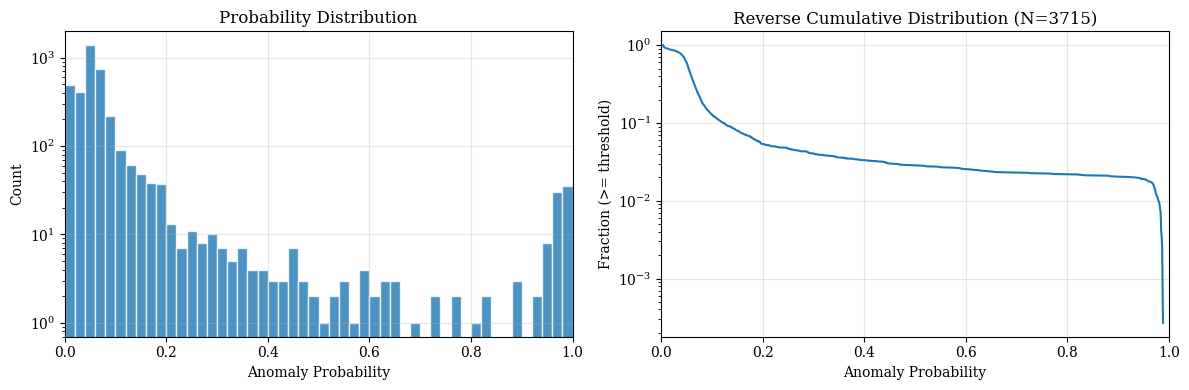

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 히스토그램
axes[0].hist(df_result["prob"], bins=np.linspace(0, 1, 51), edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Anomaly Probability")
axes[0].set_ylabel("Count")
axes[0].set_title("Probability Distribution")
axes[0].set_xlim(0, 1)
axes[0].set_yscale("log")
axes[0].grid(alpha=0.3)

# Reverse Cumulative
sorted_probs = np.sort(df_result["prob"])
cumulative = np.arange(1, len(sorted_probs) + 1)

axes[1].plot(sorted_probs, cumulative[::-1] / len(df_result))
axes[1].set_xlabel("Anomaly Probability")
axes[1].set_ylabel("Fraction (>= threshold)")
axes[1].set_title(f"Reverse Cumulative Distribution (N={len(df_result)})")
axes[1].set_xlim(0, 1)
axes[1].set_yscale("log")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

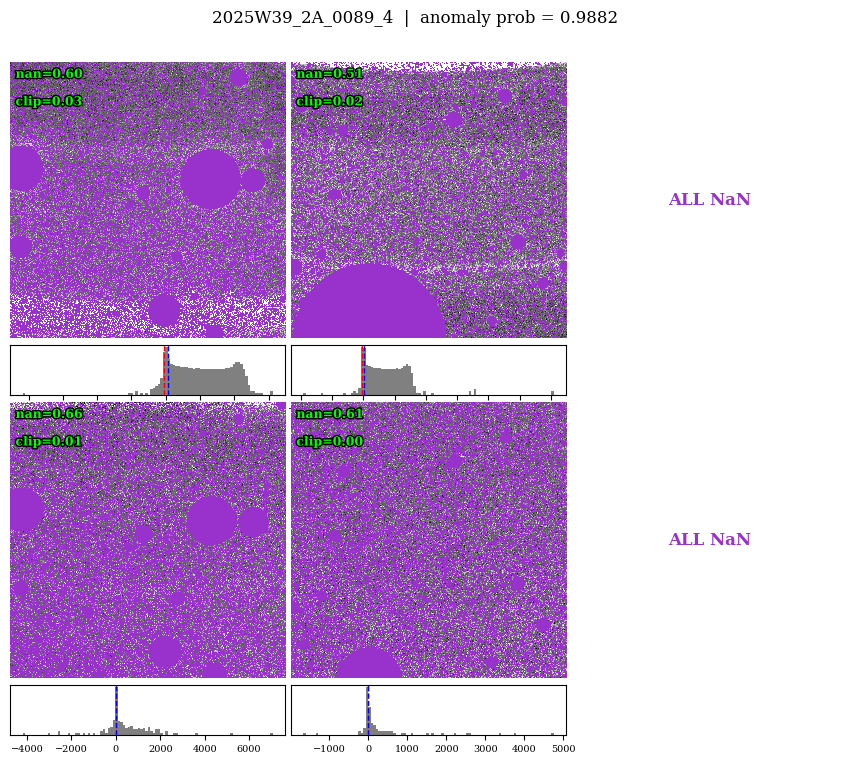

In [16]:
row = df_result.iloc[0]   # 13th sample

visualize_raw_bands(row["filepath"], prob=row["prob"])

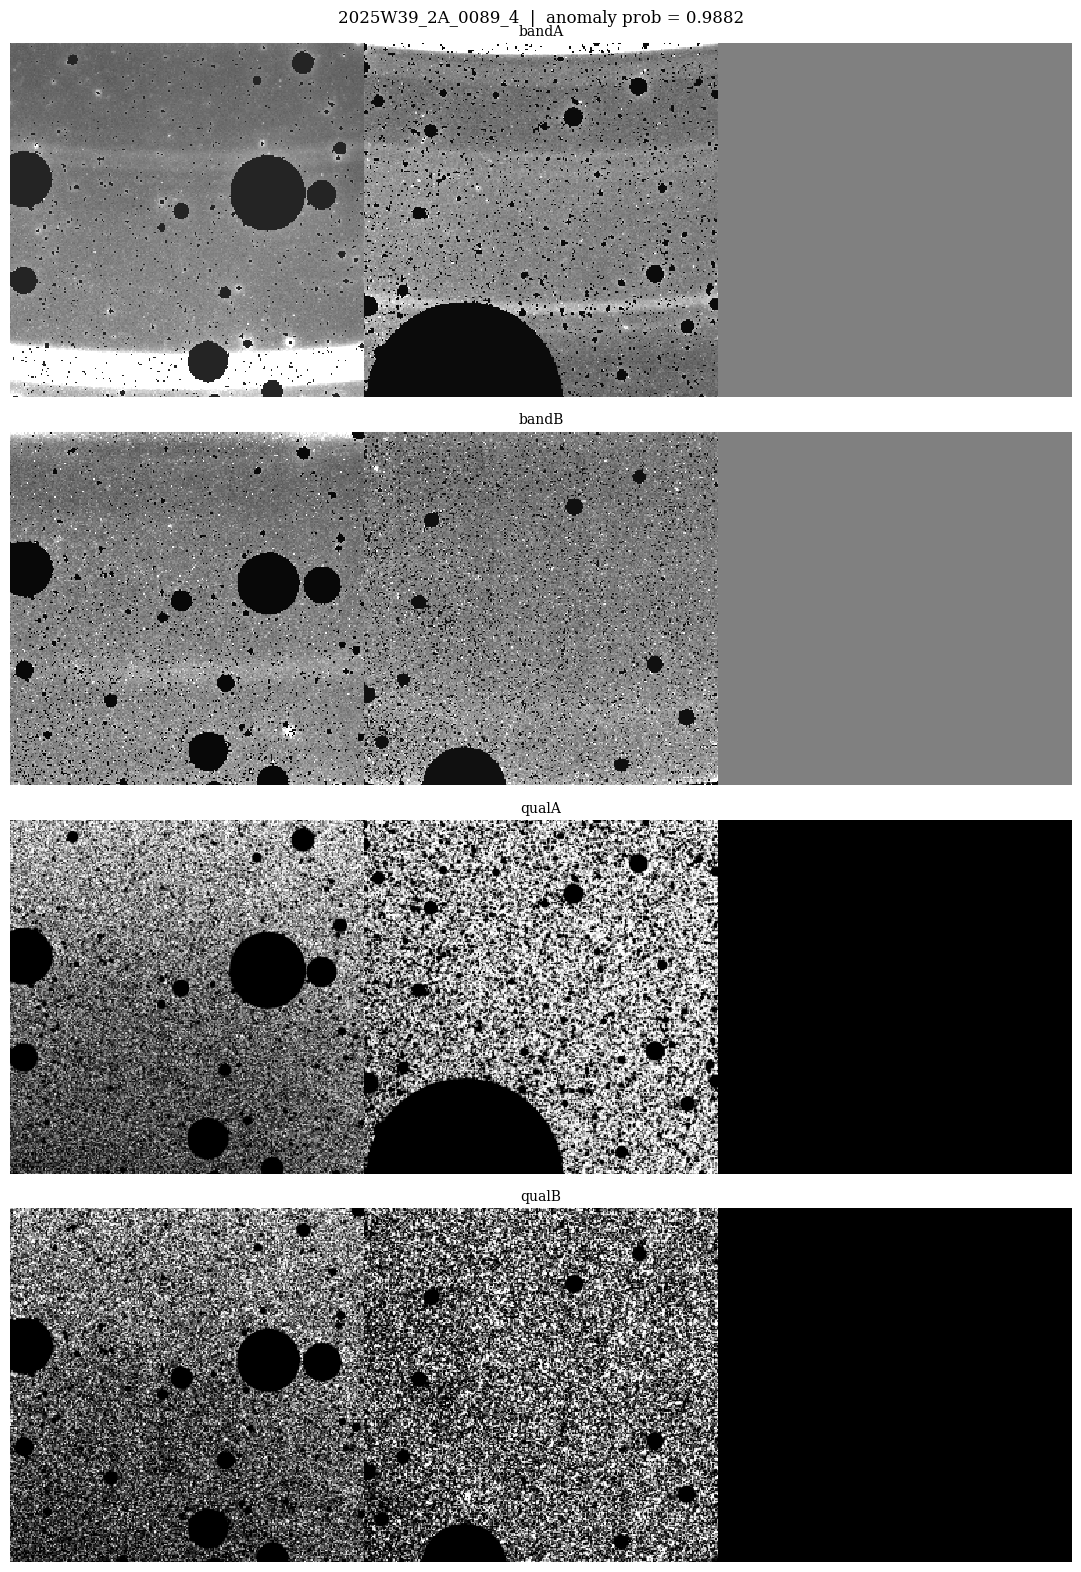

In [17]:
row = df_result.iloc[0]   # 13th sample
visualize_model_input(row["filepath"], prob=row["prob"])

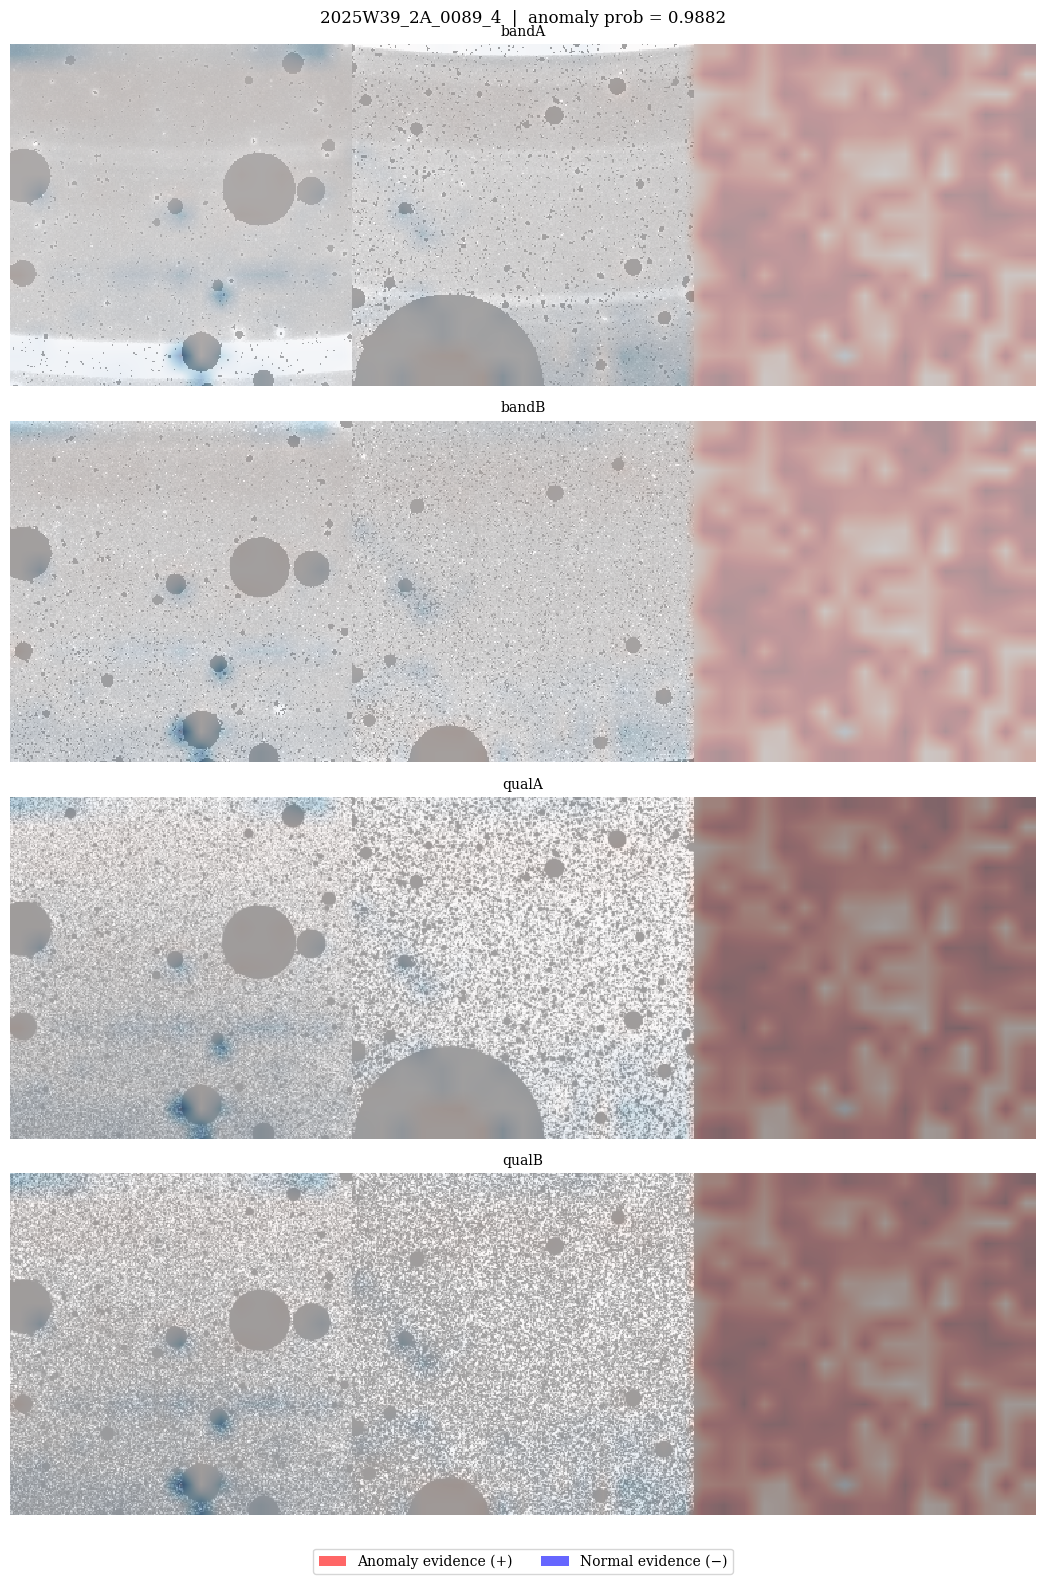

In [18]:
row = df_result.iloc[0]

prob, pos_map, neg_map = compute_grad_attention_maps(
    model, row["filepath"], device="cpu"
)
visualize_grad_attention(
    row["filepath"], pos_map, neg_map, prob=prob
)

### GIF Animations of ViT Anomaly Detector Results

In [ ]:
from PIL import Image
import io

frames = []

for idx in range(0, 80, 2):
    row = df_result.iloc[idx]
    prob, pos_map, neg_map = compute_grad_attention_maps(
        model, row["filepath"], device="cpu"
    )

    img_4ch = preprocess_file(row["filepath"])
    obsid = os.path.splitext(os.path.basename(row["filepath"]))[0]
    zmin, zmax = -5, 5

    def _norm(m):
        m = m - m.min()
        return m / (m.max() + 1e-8)

    pos_norm = _norm(pos_map)
    neg_norm = _norm(neg_map)

    cmap_gray = plt.get_cmap("gray").copy()

    fig, axes = plt.subplots(4, 1, figsize=(12, 4 * 4))
    fig.suptitle(f"{obsid}  |  anomaly prob = {prob:.4f}", fontsize=12)

    for ch in range(4):
        ax = axes[ch]
        img = img_4ch[ch]
        names = ["bandA", "bandB", "qualA", "qualB"]

        if ch < 2:
            vmin, vmax = zmin, zmax
            img_show = np.ma.masked_invalid(img)
        else:
            vmin, vmax = 0.0, 1.0
            img_show = img

        ax.imshow(img_show, origin="lower", cmap=cmap_gray,
                  vmin=vmin, vmax=vmax, interpolation="nearest", aspect="equal")
        ax.imshow(pos_norm, origin="lower", cmap="Reds", alpha=0.4, aspect="equal")
        ax.imshow(neg_norm, origin="lower", cmap="Blues", alpha=0.4, aspect="equal")
        ax.set_title(names[ch], fontsize=10)
        ax.axis("off")

    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor="red",  alpha=0.6, label="Anomaly evidence (+)"),
        Patch(facecolor="blue", alpha=0.6, label="Normal evidence (−)"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=2, fontsize=10)
    plt.tight_layout(rect=[0, 0.03, 1, 1])

    # figure → PIL Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=72)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)
    print(f"✅ idx={idx} done")

# GIF 저장
frames[0].save(
    "anomaly_grad_attention.gif",
    save_all=True,
    append_images=frames[1:],
    duration=2000,   # 1초/프레임
    loop=0
)
print("✅ Saved: anomaly_grad_attention.gif")

✅ idx=0 done
✅ idx=2 done
✅ idx=4 done
✅ idx=6 done
✅ idx=8 done
✅ idx=10 done
✅ idx=12 done
✅ idx=14 done
✅ idx=16 done
✅ idx=18 done
✅ idx=20 done
✅ idx=22 done
✅ idx=24 done
✅ idx=26 done
✅ idx=28 done
✅ idx=30 done
✅ idx=32 done
✅ idx=34 done
✅ idx=36 done
✅ idx=38 done
✅ idx=40 done
✅ idx=42 done
✅ idx=44 done
✅ idx=46 done
✅ idx=48 done
✅ idx=50 done
✅ idx=52 done
✅ idx=54 done
✅ idx=56 done
✅ idx=58 done


In [ ]:
from PIL import Image
import io

frames = []

for idx in range(100, 3500, 100):
    row = df_result.iloc[idx]
    prob, pos_map, neg_map = compute_grad_attention_maps(
        model, row["filepath"], device="cpu"
    )

    img_4ch = preprocess_file(row["filepath"])
    obsid = os.path.splitext(os.path.basename(row["filepath"]))[0]
    zmin, zmax = -5, 5

    def _norm(m):
        m = m - m.min()
        return m / (m.max() + 1e-8)

    pos_norm = _norm(pos_map)
    neg_norm = _norm(neg_map)

    cmap_gray = plt.get_cmap("gray").copy()

    fig, axes = plt.subplots(4, 1, figsize=(12, 4 * 4))
    fig.suptitle(f"{obsid}  |  anomaly prob = {prob:.4f}", fontsize=12)

    for ch in range(4):
        ax = axes[ch]
        img = img_4ch[ch]
        names = ["bandA", "bandB", "qualA", "qualB"]

        if ch < 2:
            vmin, vmax = zmin, zmax
            img_show = np.ma.masked_invalid(img)
        else:
            vmin, vmax = 0.0, 1.0
            img_show = img

        ax.imshow(img_show, origin="lower", cmap=cmap_gray,
                  vmin=vmin, vmax=vmax, interpolation="nearest", aspect="equal")
        ax.imshow(pos_norm, origin="lower", cmap="Reds", alpha=0.4, aspect="equal")
        ax.imshow(neg_norm, origin="lower", cmap="Blues", alpha=0.4, aspect="equal")
        ax.set_title(names[ch], fontsize=10)
        ax.axis("off")

    from matplotlib.patches import Patch
    legend = [
        Patch(facecolor="red",  alpha=0.6, label="Anomaly evidence (+)"),
        Patch(facecolor="blue", alpha=0.6, label="Normal evidence (−)"),
    ]
    fig.legend(handles=legend, loc="lower center", ncol=2, fontsize=10)
    plt.tight_layout(rect=[0, 0.03, 1, 1])

    # figure → PIL Image
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=72)
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)
    print(f"✅ idx={idx} done")

# GIF 저장
frames[0].save(
    "normal_grad_attention.gif",
    save_all=True,
    append_images=frames[1:],
    duration=2000,   # 1초/프레임
    loop=0
)
print("✅ Saved: normal_grad_attention.gif")

In [ ]:
from IPython.display import Image as IPImage
IPImage("anomaly_grad_attention.gif")

In [ ]:
from IPython.display import Image as IPImage
IPImage("normal_grad_attention.gif")